In [5]:
import os
os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")
import sys
import numpy as np
import pandas as pd

import scanpy as sc
import palantir

import matplotlib.pyplot as plt

In [6]:
import seaborn as sns

In [7]:
import PINN
from PINN import reader

# identify detached / weird cells

In [4]:
ad = sc.read_h5ad("data/combined_filt.h5ad")

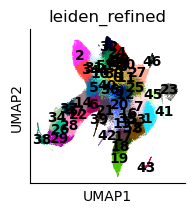

In [64]:
# sc.tl.leiden(ad, resolution=3, key_added='leiden_refined')
fig = plt.figure(figsize=(2,2))
ax = fig.gca()
sc.pl.umap(ad, color=["leiden_refined"], legend_loc='on data', ax=ax, return_fig=False)

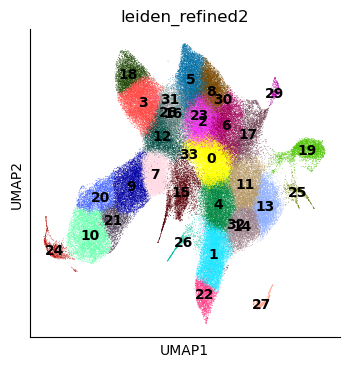

In [59]:
sc.tl.leiden(ad, resolution=1.5, key_added='leiden_refined2')
sc.pl.umap(ad, color=["leiden_refined2"], legend_loc='on data')

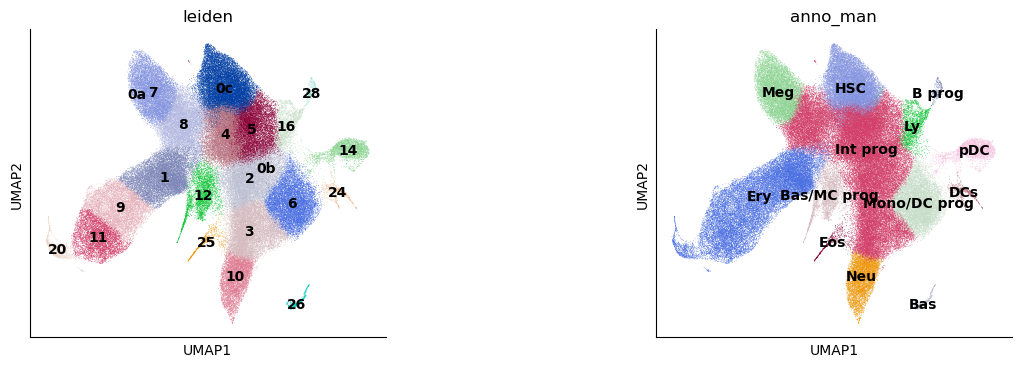

In [46]:
sc.pl.umap(ad, color=["leiden",'anno_man'], wspace=0.6, legend_loc='on data')

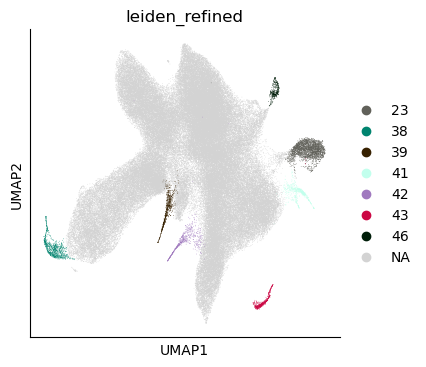

In [57]:
weird_cluster = ['39', '38', '42', '43', '23', '41', '46'] 
weird_cells = ad.obs.query("`leiden_refined` in @weird_cluster ").index
sc.pl.umap(ad, color='leiden_refined', groups=weird_cluster)

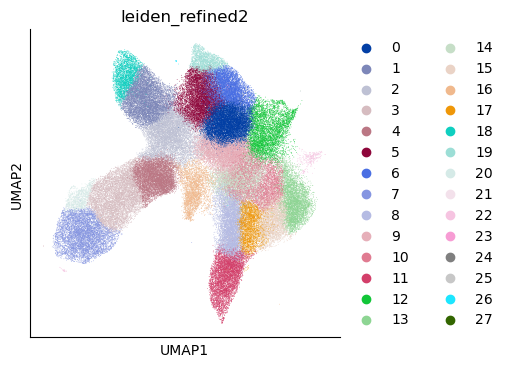

In [19]:
sc.pl.umap(ad, color='leiden_refined2')

In [ ]:
sc.tl.leiden(ad, resolution=1.5, key_added='leiden_refined2')

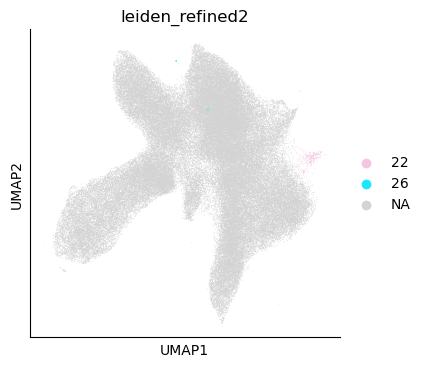

In [ ]:
sc.pl.umap(ad, color='leiden_refined2', groups=['26', '22'])

In [27]:
X_umap = ad.obsm['X_umap']

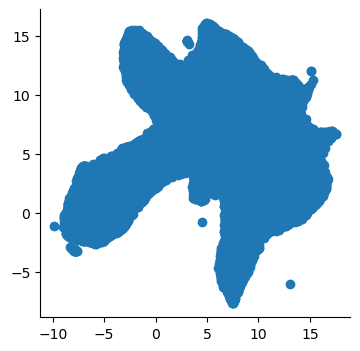

In [28]:
plt.scatter(X_umap[:,0], X_umap[:,1])

In [50]:
X_in = np.logical_and(X_umap[:,0] <5, X_umap[:,0] > 4)
Y_in = np.logical_and(X_umap[:,1] <0, X_umap[:,1] > -1)
cell_inrange = np.logical_and(X_in, Y_in)
out_cell1 = np.where(cell_inrange)[0].item()

cell_inrange = np.logical_and(X_umap[:,0] >10, X_umap[:,1] <-5)
out_cell2 = np.where(cell_inrange)[0].item()

In [51]:
out_groups = ['26', '22']
outgroup_cbs = list(ad.obs.query("`leiden_refined2` in @out_groups").index)
outgroup_cbs += [ad.obs_names[out_cell1]]
outgroup_cbs += [ad.obs_names[out_cell2]]

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

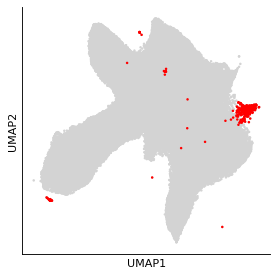

In [54]:
fig = plt.figure(dpi=80)
ax = fig.gca()

sc.pl.umap(ad, return_fig=False, show=False, ax=ax, size=20)
sc.pl.umap(ad[outgroup_cbs], na_color='red', return_fig=False, show=False, ax=ax, size=20)

In [57]:
weird_cbs = pd.read_table("data/weird_cell_barcodes.txt")['cellbarcode'].values.tolist()
print(len(weird_cbs))
weird_cbs +=  outgroup_cbs
print(len(weird_cbs))

with open("data/weird_cell_barcodes.txt", "w") as f:
    f.write("cellbarcode\n")

    for cb in weird_cbs:
        f.write(f"{cb}\n")
    f.close()

6433
6774


In [60]:

# remove detached cells
ad = ad[[cb for cb in ad.obs_names if cb not in weird_cbs]].copy()
aged_mouse_ids = [id for id in ad.obs['biosample_id'].unique() if 'old' in id]
young_mouse_cbs = ad.obs.query("`biosample_id` not in @aged_mouse_ids").index


with open("data/continurous_young_mouse_cbs.txt", "w") as f:

    f.write("cellbarcode\n")

    for cb in young_mouse_cbs:
        f.write(f"{cb}\n")

    f.close()

In [ ]:

ad = ad[young_mouse_cbs].copy()
ad

# filter cells

In [4]:
young_mouse_cb = pd.read_table("data/continurous_young_mouse_cbs.txt")['cellbarcode'].values.tolist()

In [5]:
ad = sc.read_h5ad("data/combined_filt.h5ad")
ad = ad[young_mouse_cb].copy()
ad

AnnData object with n_obs × n_vars = 112003 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', '

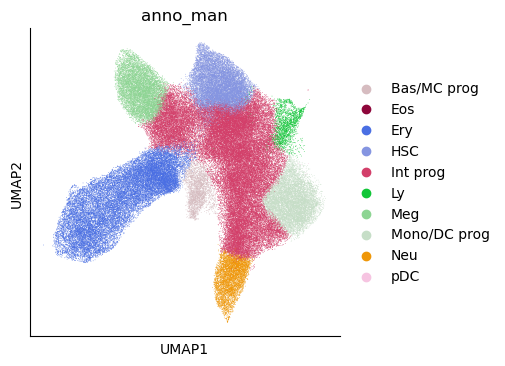

In [64]:
sc.pl.umap(ad, color=['anno_man'])

In [6]:
tompos_df = pd.read_csv("data/model_input_tompos.csv")
tomneg_df = pd.read_csv("data/model_input_tomneg.csv")

tompos_df['log_total'] = tompos_df['flow_total'].apply(np.log10)
tomneg_df['log_total'] = tomneg_df['flow_total'].apply(np.log10)

tompos_df['log_total'] = tompos_df['flow_total'].apply(np.log10)
tomneg_df['log_total'] = tomneg_df['flow_total'].apply(np.log10)

Text(0.5, 1.0, 'pop size of tom - cells')

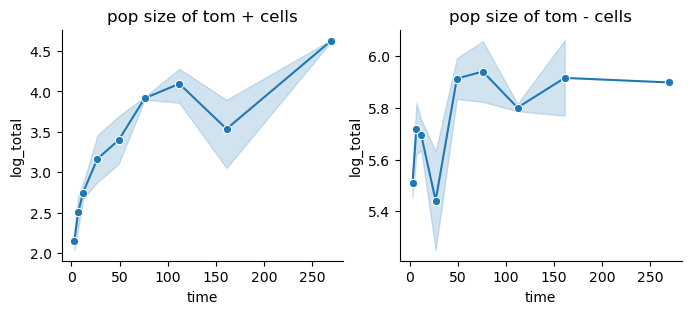

In [7]:
fig, axs = plt.subplots(1,2, figsize=(8,3))
sns.lineplot(data=tompos_df, x='time', y='log_total', marker='o', ax=axs[0])
sns.lineplot(data=tomneg_df, x='time', y='log_total', marker='o', ax=axs[1])

axs[0].set_title("pop size of tom + cells")
axs[1].set_title("pop size of tom - cells")

In [ ]:
tompos = ad[ad.obs.tom == 'pos'].copy()
tompos

AnnData object with n_obs × n_vars = 49390 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [72]:
pop = {}
pop['t'] = sorted(tompos_df.time.unique())
pop['mean'] = tompos_df.groupby('time').agg({'flow_total':'mean'})['flow_total'].values
pop['var'] = tompos_df.groupby('time').agg({'flow_total':'std'})['flow_total'].values
pop['n_lib'] = tompos_df.groupby("time").agg({'biosample_id':'count'})['biosample_id'].values.tolist()

In [81]:
tompos.uns['pop'] = pop

In [85]:
tompos.write_h5ad("data/tom_pos.h5ad")

## split train val

In [8]:
tompos = sc.read_h5ad("data/tom_pos_updated.h5ad")

In [14]:
tompos

AnnData object with n_obs × n_vars = 49390 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [9]:
obs = tompos.obs

In [26]:
def train_test_split_adata(adata,  leaveout=None, val_size=0.1, test_size=0.1, timepoint_key='timepoint_tx_days'):

    obs = adata.obs
    val_test_cbs = obs.query(f"`{timepoint_key}` not in @leaveout").sample(frac=0.2).index
    test_cb = np.random.choice(val_test_cbs, size=len(val_test_cbs)//2,replace=False)

    split_mapper = {cb:'test' for cb in test_cb}
    val_cbs = {cb:'val' for cb in val_test_cbs if cb not in test_cb}
    train_cbs = {cb:'train' for cb in adata.obs_names if cb not in val_test_cbs}

    split_mapper.update(val_cbs)
    split_mapper.update(train_cbs)

    return adata.obs.index.map(split_mapper)

In [31]:
tompos.obs['split'] = train_test_split_adata(tompos, leaveout=[3])

In [32]:
tompos.obs['split'].value_counts()

split
train    39591
val       4900
test      4899
Name: count, dtype: int64

In [33]:
tompos.write_h5ad("data/tom_pos_updated.h5ad")

# refine annotation

In [ ]:
tompos = sc.read_h5ad("data/tom_pos_updated.h5ad")

In [ ]:
tompos.obs['fine_anno'] = tompos.obs['anno_man'].astype("object")

In [ ]:
leidens = ['0c', '8', '7','1']
mep_cbs = tompos.obs.query("`leiden` in @leidens & `anno_man` == 'Int prog'").index
tompos.obs.loc[mep_cbs ,'fine_anno'] = 'Meg/Ery prog'

In [ ]:
rename_dict = dict(zip(tompos.obs['fine_anno'].unique(),tompos.obs['fine_anno'].unique()))
rename_dict.update({'Eos':'Eos prog', 'Neu':'Neu prog', 'Meg':'Meg prog', 'Ery':'Ery prog'})
tompos.obs['fine_anno'] = tompos.obs['fine_anno'].map(rename_dict)

In [ ]:
old_palette = dict( zip(tompos.obs['anno_man'].cat.categories, tompos.uns['anno_man_colors'])) 
new_palette = {'Meg/Ery prog':'#7f7f7f'}

for ct, hex in old_palette.items():
    new_ct = rename_dict[ct]
    new_palette[new_ct] = hex

In [ ]:
tompos.obs['fine_anno'] = pd.Categorical(
    tompos.obs['fine_anno'].values,
    ['HSC', 'Int prog',  'Meg/Ery prog', 'Meg prog', 'Ery prog', 'Bas/MC prog', 'Eos prog',  'Mono/DC prog', 'Neu prog', 'Ly']
    )
tompos.uns['fine_anno_colors'] = [new_palette[ct] for ct in tompos.obs['fine_anno'].cat.categories]

In [ ]:
tompos.write_h5ad("data/tom_pos_updated.h5ad")
tompos.write_h5ad("data/tom_pos.h5ad")

In [ ]:
from matplotlib.gridspec import GridSpec

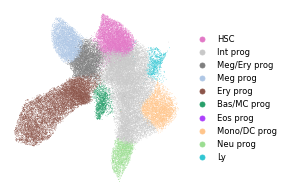

In [ ]:
fig = plt.figure(figsize=(6,4), dpi=60, frameon=False)
gs = GridSpec(1, 3)
ax1 = fig.add_subplot(gs[0:2])
sc.pl.umap(adata, color='fine_anno', frameon=False,  ax=ax1, title='')
# fig.savefig("results/tompos_celltype.pdf", format="pdf",transparent=True)

# tom negative cells

In [8]:
tomneg = ad[ad.obs.tom == 'neg'].copy()
tomneg

AnnData object with n_obs × n_vars = 62613 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [9]:
pop = {}
pop['t'] = sorted(tomneg_df.time.unique())
pop['mean'] = tomneg_df.groupby('time').agg({'flow_total':'mean'})['flow_total'].values
pop['var'] = tomneg_df.groupby('time').agg({'flow_total':'std'})['flow_total'].values
pop['n_lib'] = tomneg_df.groupby("time").agg({'biosample_id':'count'})['biosample_id'].values.tolist()

tomneg.uns['pop'] = pop

In [10]:
tomneg.write_h5ad("data/tom_neg.h5ad")

In [11]:
tomneg.uns['pop']

{'t': [3, 7, 12, 27, 49, 76, 112, 161, 269],
 'mean': array([326325.2130927 , 538515.00000005, 500258.58416266, 303870.35760186,
        832689.2321673 , 904551.3155864 , 632851.37840159, 871245.94985872,
        791790.94053407]),
 'var': array([ 58607.53709332, 170510.31500179,  97014.35097037, 178552.08078564,
        211348.50436874, 337342.16492759,  28916.81029027, 398748.14647747,
                    nan]),
 'n_lib': [2, 2, 2, 2, 2, 2, 2, 2, 2]}